In [37]:
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from difflib import SequenceMatcher

import re

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# 1. load data
df = pd.read_csv("/Users/zphilipp/Downloads/bq-results-20250730-130837-1753881075041.csv")
df['searchString'] = df['searchString'].str.strip().str.lower()
df['suggestionView'] = df['suggestionView'].str.strip().str.lower()

# 2. agg
grouped = df.groupby(['searchString', 'suggestionView'], as_index=False).agg({
    'searchCount': 'sum',
    'suggestionClicks': 'sum',
    'dealClicks': 'sum',
    'dealPurchased': 'sum'
})

In [63]:
def compute_label(row):
    # High confidence if exact match
    if row.get('is_exact_match', 0) == 1:
        return 1.0

    # Funnel-based weights
    ctr = row['suggestionClicks'] / row['searchCount'] if row['searchCount'] > 0 else 0
    deal_click_rate = row['dealClicks'] / row['suggestionClicks'] if row['suggestionClicks'] > 0 else 0
    cvr = row['dealPurchased'] / row['dealClicks'] if row['dealClicks'] > 0 else 0

    # Assign meaningful funnel progression weights
    funnel_score = (
        1.0 * ctr +
        2.0 * deal_click_rate +
        4.0 * cvr +
        0.5 * int(row['dealPurchased'] > 0)
    )
    label = funnel_score

    # Bonus for purchase (strong signal)
    #if row['dealPurchased'] > 0:
    #    label += 0.5
        
    # Bonus for is_exact_match (but not hard override)
    if row.get('is_exact_match', 0) == 1:
        label += 0.5
        
    # Bonus for "starts with same word"
    if row.get('starts_with_same_word', 0) == 1:
        s1 = str(row['searchString']).lower()
        s2 = str(row['suggestionView']).lower()

        count = 0
        for ch1, ch2 in zip(s1, s2):
            if ch1 == ch2:
                count += 1
            else:
                break

        bonus_per_char = 0.05  # Less aggressive than before
        bonus = max(0, (count - 1) * bonus_per_char)
        label += bonus

    # Small bonus for partial text matches
    label += 0.05 * row.get('text_similarity', 0)

    return min(label, 1.0)
    
def add_text_features(df):
    
    def char_similarity(a, b):
        return SequenceMatcher(None, a.lower(), b.lower()).ratio()
    
    # Word overlap
    def word_overlap_count(str1, str2):
        set1 = set(str(str1).lower().split())
        set2 = set(str(str2).lower().split())
        return len(set1 & set2)

    # Features
    df['text_similarity'] = df.apply(lambda row: char_similarity(row['searchString'], row['suggestionView']), axis=1)
    df['length_diff'] = df.apply(lambda row: abs(len(str(row['searchString'])) - len(str(row['suggestionView']))), axis=1)
    df['word_overlap_count'] = df.apply(lambda row: word_overlap_count(row['searchString'], row['suggestionView']), axis=1)
    df['starts_with_same_word'] = df.apply(
        lambda row: int(str(row['searchString']).split()[0].lower() == str(row['suggestionView']).split()[0].lower())
        if row['searchString'] and row['suggestionView'] else 0, axis=1)
    df['is_exact_match'] = df.apply(lambda row: int(str(row['searchString']).strip().lower() == str(row['suggestionView']).strip().lower()), axis=1)
    df['is_suggest_in_search'] = df.apply(lambda row: int(str(row['suggestionView']).lower() in str(row['searchString']).lower()), axis=1)
    df['is_search_in_suggest'] = df.apply(lambda row: int(str(row['searchString']).lower() in str(row['suggestionView']).lower()), axis=1)
    df['is_prefix_match'] = df.apply(lambda row: int(
        str(row['searchString']).lower().startswith(str(row['suggestionView']).lower()) or
        str(row['suggestionView']).lower().startswith(str(row['searchString']).lower())), axis=1)

    return df

grouped = add_text_features(grouped)
grouped['label'] = grouped.apply(compute_label, axis=1)

In [64]:
grouped.query("label > 0.2 and label < 0.3").head(100)

,searchString,suggestionView,searchCount,suggestionClicks,dealClicks,dealPurchased,text_similarity,length_diff,word_overlap_count,starts_with_same_word,is_exact_match,is_suggest_in_search,is_search_in_suggest,is_prefix_match,label
242,1 day univ,1 day,1,0,0,0,0.666667,5,2,1,0,1,0,1,0.233333
490,13 ga,13 gallon trash can,1,0,0,0,0.416667,14,1,1,0,0,1,1,0.220833
537,14 kt gold,14 kt,1,0,0,0,0.666667,5,2,1,0,1,0,1,0.233333
745,2 day,2 day cruise,1,0,0,0,0.588235,7,2,1,0,0,1,1,0.229412
769,2 day sa,2 day,1,0,0,0,0.769231,3,2,1,0,1,0,1,0.238462
807,2 piercin,2 piece,1,0,0,0,0.750000,2,1,1,0,0,0,0,0.237500
960,21st b,21st birthday,1,0,0,0,0.631579,7,1,1,0,0,1,1,0.281579
1263,30 in,30 inch luggage,1,0,0,0,0.500000,10,1,1,0,0,1,1,0.225000
1593,3d br,3d brows,1,0,0,0,0.769231,3,1,1,0,0,1,1,0.238462
1726,4 hand,4 hand full body massage,1,0,0,0,0.400000,18,2,1,0,0,1,1,0.270000


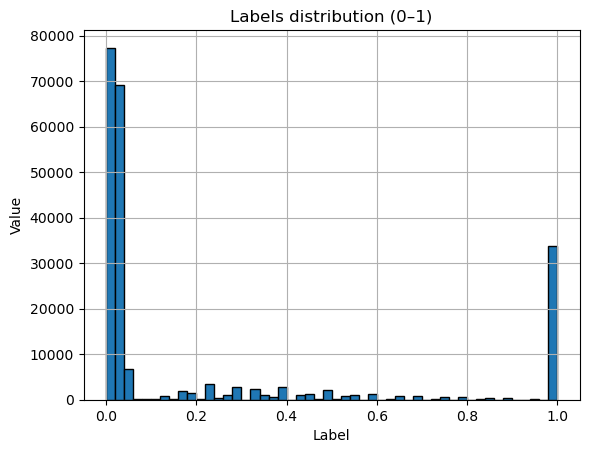

In [65]:
plt.hist(grouped['label'], bins=50, edgecolor='black')
plt.title("Labels distribution (0–1)")
plt.xlabel("Label")
plt.ylabel("Value")
plt.grid(True)
plt.show()

In [66]:
# prepare labeled data for training
X = grouped.drop(columns=['searchString', 'suggestionView', 'label'])

y = grouped['label']

# data split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# model train
model = GradientBoostingRegressor()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Matrics Root mean square error
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R² score: {r2:.4f}")

RMSE: 0.0440
R² score: 0.9854


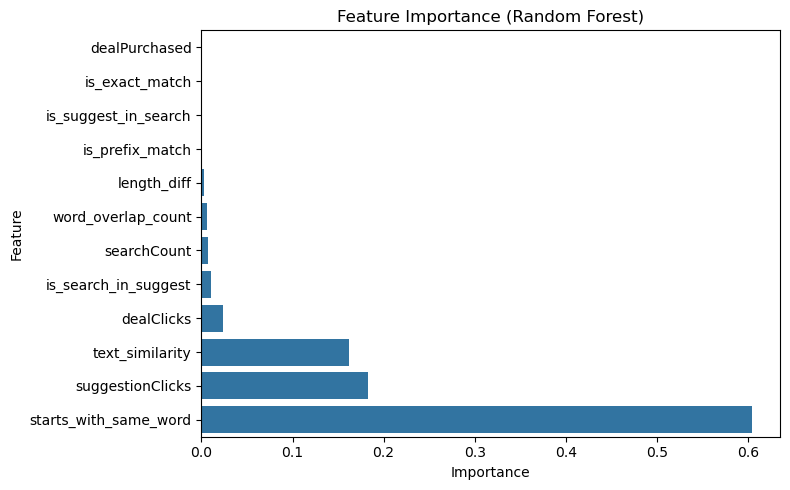

In [67]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(8, 5))
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()

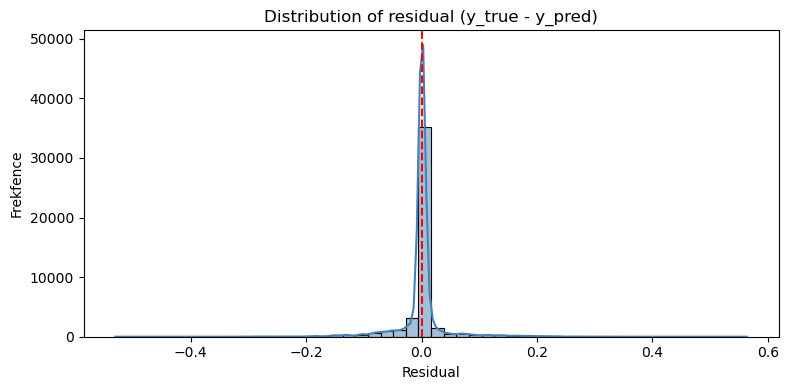

In [26]:
# residuals
y_pred = model.predict(X_test)
residuals = y_test - y_pred

# Histogram of residuals
plt.figure(figsize=(8, 4))
sns.histplot(residuals, bins=50, kde=True, color='steelblue')
plt.title('Distribution of residual (y_true - y_pred)')
plt.xlabel('Residual')
plt.ylabel('Frekfence')
plt.axvline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

In [27]:
# Prediction
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Metrics
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)

# RMSE (Root Mean Squared Error)
# Meaning of Metrics
# Metric = Meaning
# RMSE (Root Mean Squared Error) = Measures the average magnitude of the prediction errors. It’s the square root of the average of squared differences between predicted and actual values. Lower RMSE means better performance.
# R² (R-squared / Coefficient of Determination)	= Indicates how well the model explains the variability of the target variable. Ranges from 0 to 1, where 1 means perfect fit. Higher values indicate that the model captures more of the variance.

# For example
# RMSE ~ 0.055 → Model predictions are, on average, only 0.055 units off from the true label (on a scale from 0 to 1), which is very small — good accuracy.
# R² ~ 0.98 → Model explains 98% of the variance in the target values — an excellent fit.
# The similarity between train and test results indicates good generalization, i.e., no overfitting.
print(f"Train RMSE: {rmse_train:.4f}, R²: {r2_train:.4f}")
print(f"Test  RMSE: {rmse_test:.4f}, R²: {r2_test:.4f}")

Train RMSE: 0.0416, R²: 0.9856
Test  RMSE: 0.0422, R²: 0.9852


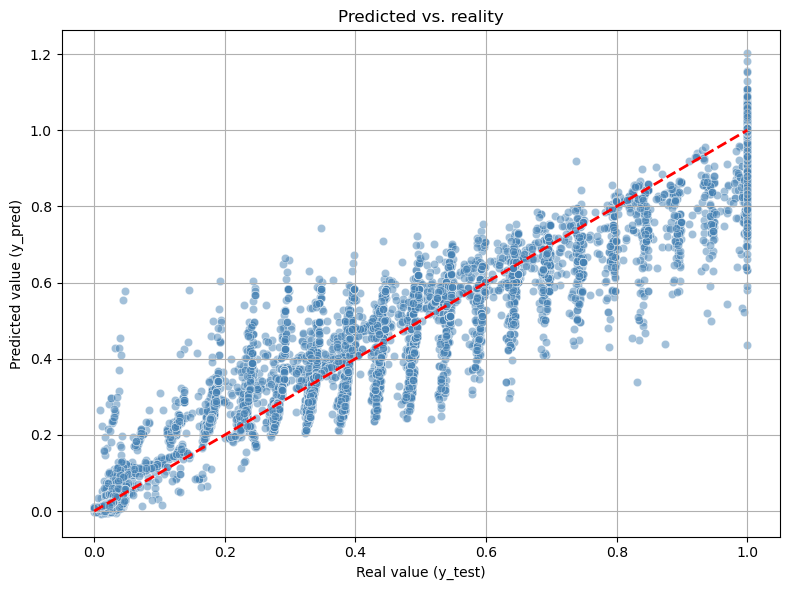

In [28]:
# Prediction
y_pred = model.predict(X_test)

# Scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='steelblue')

# Ideal linie: y = x
plt.plot([0, 1], [0, 1], 'r--', linewidth=2)

plt.xlabel('Real value (y_test)')
plt.ylabel('Predicted value (y_pred)')
plt.title('Predicted vs. reality')
plt.grid(True)
plt.tight_layout()
plt.show()

### Example of prediction

In [29]:
new_data = pd.DataFrame([{
    'searchString': '360 chi',
    'suggestionView': '360 chicago',
    'searchCount': 1,
    'suggestionClicks': 1,
    'dealClicks': 1,
    'dealPurchased': 1
}])
new_data = add_text_features(new_data)

In [30]:
feature_cols = [
    'searchCount', 'suggestionClicks', 'dealClicks', 'dealPurchased',
    'text_similarity', 'length_diff', 'word_overlap_count',
    'starts_with_same_word', 'is_exact_match', 'is_suggest_in_search',
    'is_search_in_suggest', 'is_prefix_match'
]
X_new = new_data[feature_cols]

In [31]:
predicted_label = model.predict(X_new)[0]

In [32]:
print(f"Predicted label for '{new_data.iloc[0]['searchString']}' vs '{new_data.iloc[0]['suggestionView']}': {predicted_label:.4f}")

Predicted label for '360 chi' vs '360 chicago': 0.9152
